<a href="https://colab.research.google.com/github/seankim8724/AIFFEL_quest_eng/blob/main/Data_Analysis/DA02/DA02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
from os.path import join

import pandas as pd
import numpy as np

import missingno as msno

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_data_path = join('/content/train.csv')
sub_data_path = join('/content/test.csv')

## 1. 데이터 살펴보기
pandas의 read_csv 함수를 사용해 데이터를 읽어오고, 각 변수들이 나타내는 의미를 살펴보겠습니다.
1. ID : 집을 구분하는 번호
2. date : 집을 구매한 날짜
3. price : 타겟 변수인 집의 가격
4. bedrooms : 침실의 수
5. bathrooms : 침실당 화장실 개수
6. sqft_living : 주거 공간의 평방 피트
7. sqft_lot : 부지의 평방 피트
8. floors : 집의 층 수
9. waterfront : 집의 전방에 강이 흐르는지 유무 (a.k.a. 리버뷰)
10. view : 집이 얼마나 좋아 보이는지의 정도
11. condition : 집의 전반적인 상태
12. grade : King County grading 시스템 기준으로 매긴 집의 등급
13. sqft_above : 지하실을 제외한 평방 피트
14. sqft_basement : 지하실의 평방 피트
15. yr_built : 집을 지은 년도
16. yr_renovated : 집을 재건축한 년도
17. zipcode : 우편번호
18. lat : 위도
19. long : 경도
20. sqft_living15 : 2015년 기준 주거 공간의 평방 피트(집을 재건축했다면, 변화가 있을 수 있음)
21. sqft_lot15 : 2015년 기준 부지의 평방 피트(집을 재건축했다면, 변화가 있을 수 있음)

In [3]:
data = pd.read_csv(train_data_path)
sub = pd.read_csv(sub_data_path)
print('train data dim : {}'.format(data.shape))
print('sub data dim : {}'.format(sub.shape))

train data dim : (15035, 21)
sub data dim : (6468, 20)


In [4]:
# 타겟 변수 분리 (log1p 변환 적용 - 치우친 분포를 정규분포에 가깝게 만듦)
y = np.log1p(data['price'])

del data['price']

In [5]:
train_len = len(data)
data = pd.concat((data, sub), axis=0).reset_index(drop=True)

In [6]:
data.head()

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


## 2. 간단한 전처리
각 변수들에 대해 결측 유무를 확인하고, 분포를 확인해보면서 간단하게 전처리를 하겠습니다.
### 결측치 확인
먼저 데이터에 결측치가 있는지를 확인하겠습니다.<br>
missingno 라이브러리의 matrix 함수를 사용하면, 데이터의 결측 상태를 시각화를 통해 살펴볼 수 있습니다.

<Axes: >

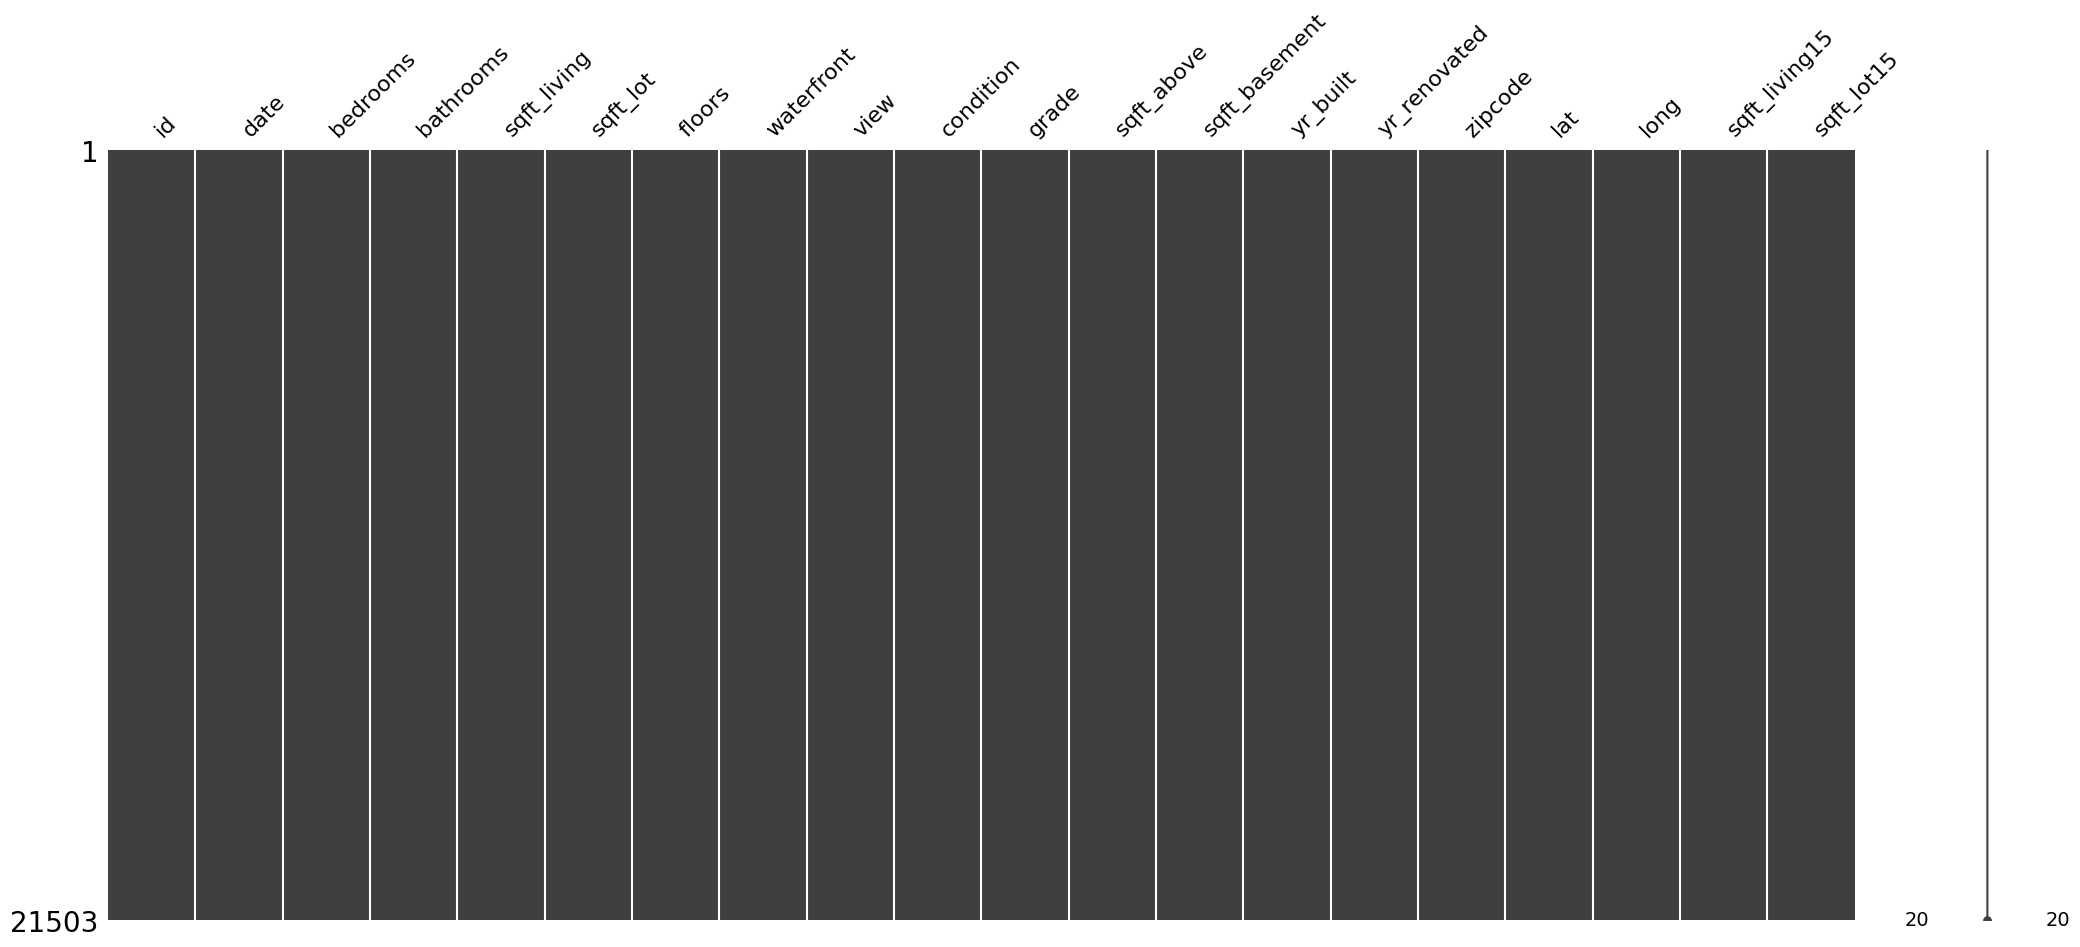

In [7]:
msno.matrix(data)

모든 변수에 결측치가 없는 것으로 보이지만, 혹시 모르니 확실하게 살펴보겠습니다.<br>

In [10]:
for c in data.columns:
    print('{} : {}'.format(c, len(data.loc[pd.isnull(data[c]), c].values)))

bedrooms : 0
bathrooms : 0
sqft_living : 0
sqft_lot : 0
floors : 0
waterfront : 0
view : 0
condition : 0
grade : 0
sqft_above : 0
sqft_basement : 0
yr_built : 0
yr_renovated : 0
zipcode : 0
lat : 0
long : 0
sqft_living15 : 0
sqft_lot15 : 0
sale_year : 0
sale_month : 0


### id, date 변수 정리
id 변수는 모델이 집값을 예측하는데 도움을 주지 않으므로 제거합니다.<br>
date 변수는 연월일시간으로 값을 가지고 있는데, 연도와 월을 분리하여 숫자형 변수로 만들겠습니다.

In [9]:
sub_id = data['id'][train_len:]
del data['id']

# date에서 연도, 월 추출 후 삭제
data['sale_year'] = data['date'].apply(lambda x: int(str(x)[:4]))
data['sale_month'] = data['date'].apply(lambda x: int(str(x)[4:6]))
del data['date']

### 피처 엔지니어링
기존 변수들을 활용하여 집값 예측에 도움이 될 새로운 변수를 추가합니다.

In [11]:
# 건물 나이
data['building_age'] = data['sale_year'] - data['yr_built']

# 리모델링 여부 및 리모델링 후 경과 연수
data['is_renovated'] = (data['yr_renovated'] > 0).astype(int)
data['years_since_renovation'] = data.apply(
    lambda row: row['sale_year'] - row['yr_renovated'] if row['yr_renovated'] > 0
    else row['building_age'], axis=1)

# 총 방 수
data['total_rooms'] = data['bedrooms'] + data['bathrooms']

# 침실당 면적
data['sqft_per_bedroom'] = data['sqft_living'] / (data['bedrooms'].clip(lower=1))

# 면적 비율
data['living_lot_ratio'] = data['sqft_living'] / (data['sqft_lot'] + 1)
data['above_living_ratio'] = data['sqft_above'] / (data['sqft_living'] + 1)
data['basement_ratio'] = data['sqft_basement'] / (data['sqft_living'] + 1)

# 지하실 유무
data['has_basement'] = (data['sqft_basement'] > 0).astype(int)

# 2015년 대비 면적 변화 (리모델링 효과 반영)
data['living_change'] = data['sqft_living15'] - data['sqft_living']
data['lot_change'] = data['sqft_lot15'] - data['sqft_lot']

# 층당 면적
data['sqft_per_floor'] = data['sqft_living'] / data['floors']

# 위치 기반: zipcode별 평균 grade (지역 수준 반영)
# train 데이터만 사용해서 만들어야 data leakage 방지
zipcode_grade = data.iloc[:train_len].groupby('zipcode')['grade'].mean()
data['zipcode_mean_grade'] = data['zipcode'].map(zipcode_grade)
data['zipcode_mean_grade'] = data['zipcode_mean_grade'].fillna(data['grade'])

# 위치 기반: lat, long 조합 (강남 프리미엄 같은 효과)
data['lat_long'] = data['lat'] * data['long']
data['lat2'] = data['lat'] ** 2
data['long2'] = data['long'] ** 2

print('피처 엔지니어링 완료! 현재 컬럼 수:', data.shape[1])

피처 엔지니어링 완료! 현재 컬럼 수: 36


### 각 변수들의 분포 확인
한쪽으로 치우친 분포는 모델이 결과를 예측하기에 좋지 않은 영향을 미치므로 다듬어줄 필요가 있습니다.

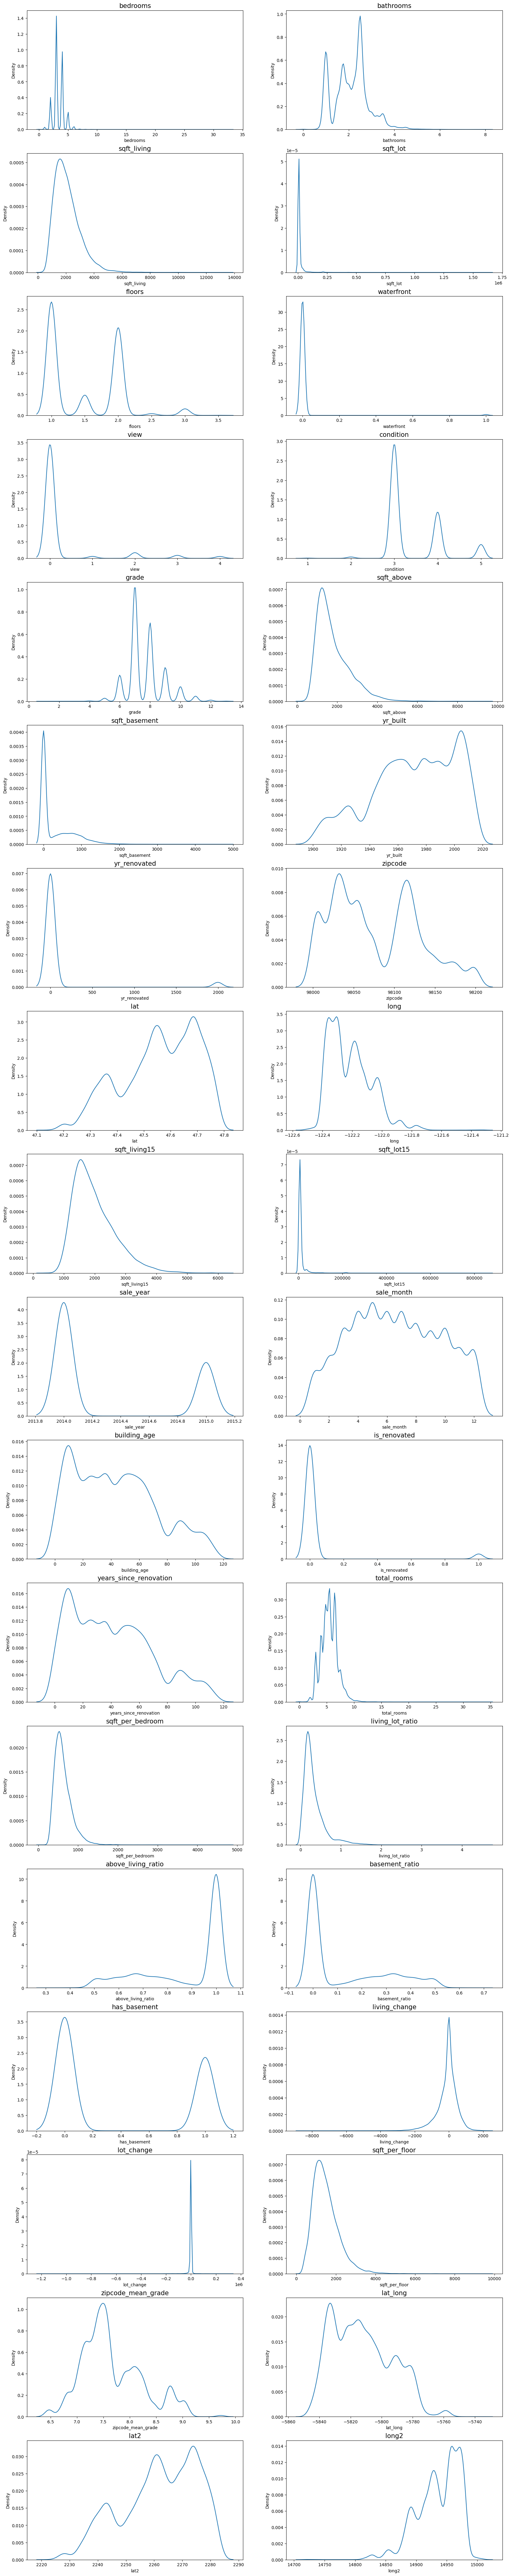

In [12]:
num_columns = data.select_dtypes(include=['number']).columns
n_cols = len(num_columns)
n_rows = (n_cols + 1) // 2

fig, ax = plt.subplots(n_rows, 2, figsize=(20, n_rows * 6))

count = 0
for row in range(n_rows):
    for col in range(2):
        if count >= n_cols:
            break
        sns.kdeplot(data[num_columns[count]], ax=ax[row][col])
        ax[row][col].set_title(num_columns[count], fontsize=15)
        count += 1

bedrooms, sqft_living, sqft_lot, sqft_above, sqft_basement 변수가 한쪽으로 치우친 경향을 보였습니다.<br>
log-scaling을 통해 데이터 분포를 정규분포에 가깝게 만들어 보겠습니다.

In [13]:
skew_columns = ['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement']

for c in skew_columns:
    data[c] = np.log1p(data[c].values)

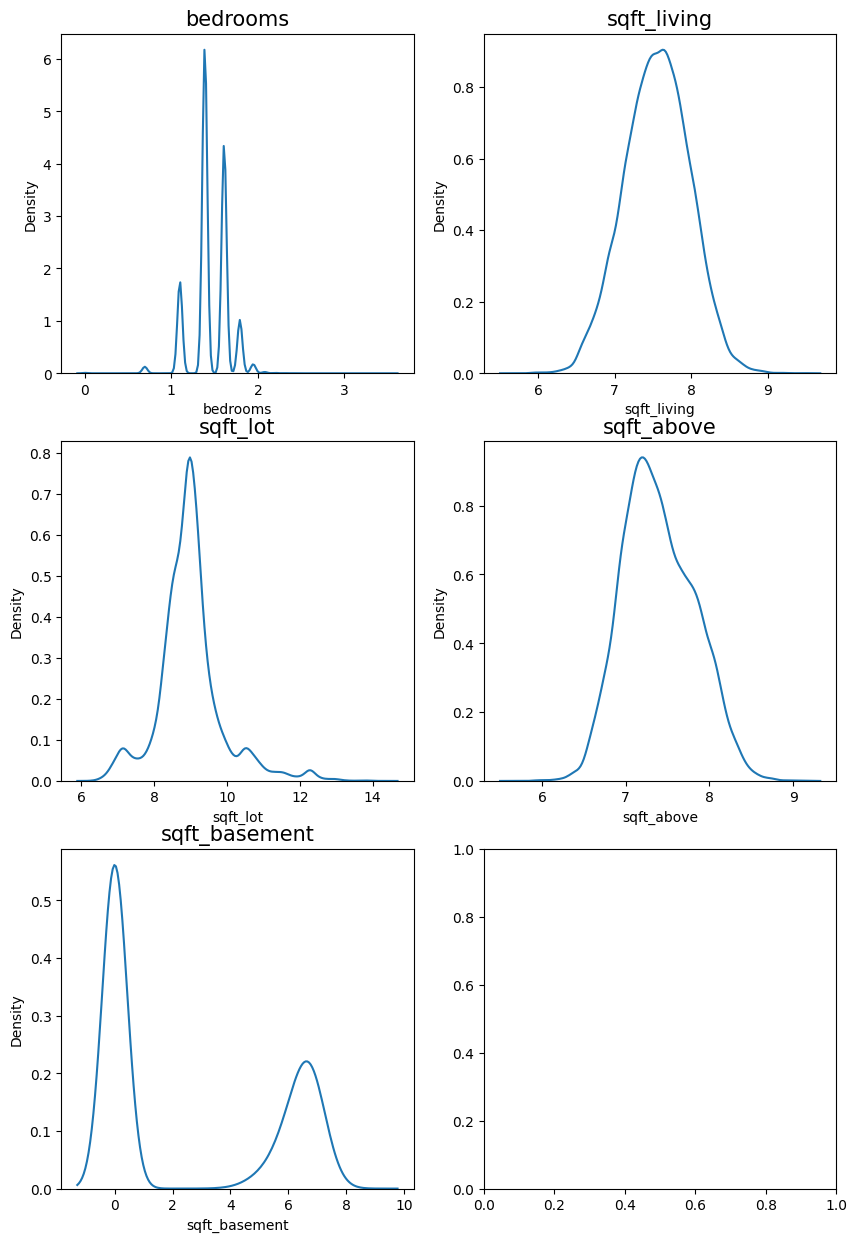

In [14]:
fig, ax = plt.subplots(3, 2, figsize=(10, 15))

count = 0
for row in range(3):
    for col in range(2):
        if count == 5:
            break
        sns.kdeplot(data[skew_columns[count]], ax=ax[row][col])
        ax[row][col].set_title(skew_columns[count], fontsize=15)
        count+=1


어느정도 치우침이 줄어든 분포를 확인할 수 있습니다.

In [15]:
sub = data.iloc[train_len:, :]
x = data.iloc[:train_len, :]

## 3. 모델링
### Average Blending
여러가지 모델의 결과를 산술 평균을 통해 Blending 모델을 만들겠습니다.

In [17]:
gboost = GradientBoostingRegressor(random_state=2019)
xgboost = xgb.XGBRegressor(random_state=2019, verbosity=0)
lightgbm = lgb.LGBMRegressor(random_state=2019, verbose=-1)

models = [{'model':gboost, 'name':'GradientBoosting'}, {'model':xgboost, 'name':'XGBoost'},
          {'model':lightgbm, 'name':'LightGBM'}]

### Cross Validation
교차 검증을 통해 모델의 성능을 간단히 평가하겠습니다.

In [18]:
def get_cv_score(models):
    kfold = KFold(n_splits=5, random_state=2019, shuffle=True).get_n_splits(x.values)
    for m in models:
        print("Model {} CV score : {:.4f}".format(m['name'], np.mean(cross_val_score(m['model'], x.values, y)),
                                             kf=kfold))

In [ ]:
get_cv_score(models)

## 4. 하이퍼파라미터 튜닝
GridSearchCV를 사용하여 각 모델의 최적 파라미터를 탐색합니다.

### 4-1. LightGBM 튜닝

In [19]:
lgb_param_grid = {
    'n_estimators': [1000, 2000, 3000],
    'max_depth': [5, 7],
    'learning_rate': [0.01, 0.03],
    'num_leaves': [31, 63],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_alpha': [0.1],
    'reg_lambda': [1.0],
}

lgb_grid = GridSearchCV(
    lgb.LGBMRegressor(random_state=2019, verbose=-1),
    param_grid=lgb_param_grid,
    scoring='neg_mean_squared_error',
    cv=KFold(n_splits=5, shuffle=True, random_state=2019),
    verbose=1, n_jobs=-1)

lgb_grid.fit(x.values, y)

print('\nLightGBM Best Parameters:', lgb_grid.best_params_)
print('LightGBM Best RMSLE: {:.6f}'.format(np.sqrt(-lgb_grid.best_score_)))

Fitting 5 folds for each of 24 candidates, totalling 120 fits

LightGBM Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 3000, 'num_leaves': 31, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.8}
LightGBM Best RMSLE: 0.158434


### 4-2. XGBoost 튜닝

In [20]:
xgb_param_grid = {
    'n_estimators': [1000, 2000, 3000],
    'max_depth': [5, 7],
    'learning_rate': [0.01, 0.03],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_alpha': [0.1],
    'reg_lambda': [1.0],
}

xgb_grid = GridSearchCV(
    xgb.XGBRegressor(random_state=2019, verbosity=0),
    param_grid=xgb_param_grid,
    scoring='neg_mean_squared_error',
    cv=KFold(n_splits=5, shuffle=True, random_state=2019),
    verbose=1, n_jobs=-1)

xgb_grid.fit(x.values, y)

print('\nXGBoost Best Parameters:', xgb_grid.best_params_)
print('XGBoost Best RMSLE: {:.6f}'.format(np.sqrt(-xgb_grid.best_score_)))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

XGBoost Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 3000, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.8}
XGBoost Best RMSLE: 0.157150


### 4-3. GradientBoosting 튜닝

In [28]:
from sklearn.model_selection import cross_val_score
import time

gb_candidates = [
    {'n_estimators': 1000, 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 0.8},
    {'n_estimators': 2000, 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 0.8},
    {'n_estimators': 1000, 'max_depth': 7, 'learning_rate': 0.03, 'subsample': 0.8},
    {'n_estimators': 2000, 'max_depth': 7, 'learning_rate': 0.03, 'subsample': 0.8},
]

best_score = -999
best_params = None

for i, p in enumerate(gb_candidates):
    print(f'\n[{i+1}/{len(gb_candidates)}] 시작: {p}')
    start = time.time()

    model = GradientBoostingRegressor(random_state=2019, **p)
    scores = cross_val_score(model, x.values, y, scoring='neg_mean_squared_error', cv=5)
    rmse = np.sqrt(-scores.mean())
    elapsed = time.time() - start

    print(f'  완료! RMSLE: {rmse:.6f} | 소요시간: {elapsed:.1f}초')

    if scores.mean() > best_score:
        best_score = scores.mean()
        best_params = p

print(f'\n=== Best Params: {best_params}')
print(f'=== Best RMSLE: {np.sqrt(-best_score):.6f}')


[1/4] 시작: {'n_estimators': 1000, 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 0.8}
  완료! RMSLE: 0.159539 | 소요시간: 653.1초

[2/4] 시작: {'n_estimators': 2000, 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 0.8}
  완료! RMSLE: 0.159151 | 소요시간: 1271.0초

[3/4] 시작: {'n_estimators': 1000, 'max_depth': 7, 'learning_rate': 0.03, 'subsample': 0.8}
  완료! RMSLE: 0.160596 | 소요시간: 892.3초

[4/4] 시작: {'n_estimators': 2000, 'max_depth': 7, 'learning_rate': 0.03, 'subsample': 0.8}
  완료! RMSLE: 0.160718 | 소요시간: 1777.1초

=== Best Params: {'n_estimators': 2000, 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 0.8}
=== Best RMSLE: 0.159151


In [29]:
# 튜닝 결과 확인
params = lgb_grid.cv_results_['params']
score = lgb_grid.cv_results_['mean_test_score']

results = pd.DataFrame(params)
results['score'] = score

results.sort_values('score', ascending=False).head()

,colsample_bytree,learning_rate,max_depth,n_estimators,num_leaves,reg_alpha,reg_lambda,subsample,score
10,0.8,0.01,7,3000,31,0.1,1.0,0.8,-0.025101
18,0.8,0.03,7,1000,31,0.1,1.0,0.8,-0.025144
8,0.8,0.01,7,2000,31,0.1,1.0,0.8,-0.025189
5,0.8,0.01,5,3000,63,0.1,1.0,0.8,-0.025265
11,0.8,0.01,7,3000,63,0.1,1.0,0.8,-0.025289


### Make Submission

회귀 모델의 경우에는 cross_val_score 함수가 R<sup>2</sup>를 반환합니다.<br>
R<sup>2</sup> 값이 1에 가까울수록 모델이 데이터를 잘 표현함을 나타냅니다. 3개 트리 모델이 상당히 훈련 데이터에 대해 괜찮은 성능을 보여주고 있습니다.<br> 훈련 데이터셋으로 튜닝된 3개 모델을 학습시키고, Average Blending을 통해 제출 결과를 만들겠습니다.

In [31]:
# best_params로 모델 생성
gb_best = GradientBoostingRegressor(random_state=2019, **best_params)

models_final = [
    {'model': gb_best, 'name': 'GradientBoosting (tuned)'},
    {'model': xgb_grid.best_estimator_, 'name': 'XGBoost (tuned)'},
    {'model': lgb_grid.best_estimator_, 'name': 'LightGBM (tuned)'}
]

In [32]:
def AveragingBlending(models, x, y, sub_x):
    for m in models :
        m['model'].fit(x.values, y)

    predictions = np.column_stack([
        m['model'].predict(sub_x.values) for m in models
    ])
    return np.mean(predictions, axis=1)

In [33]:
y_pred = AveragingBlending(models_final, x, y, sub)

# log1p 변환을 했으므로 expm1으로 원래 스케일로 복원
y_pred = np.expm1(y_pred)

In [34]:
submission = pd.DataFrame(data={'id': sub_id, 'price': y_pred})

In [35]:
submission.to_csv('submission.csv', index=False)